In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("titanic.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()
# total no. of rows and cols -  891, 12 
# Nulls present - Age, Cabin, Embarked 
# Object datatype - Name,Sex, Ticket,Cabin,Embarked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Null removal
(df.isnull().sum()/len(df))*100
'''
Cabin          77.104377 - drop the column
Age            19.865320 - depending on distribution replace with mean/median
Embarked        0.224467 - drop the rows
'''

'\nCabin          77.104377 - drop the column\nAge            19.865320 - depending on distribution replace with mean/median\nEmbarked        0.224467 - drop the rows\n'

In [5]:
df.drop("Cabin",axis=1,inplace=True)

In [6]:
print(df["Age"].median())
print(df["Age"].mean())

28.0
29.69911764705882


<Axes: xlabel='Age', ylabel='Density'>

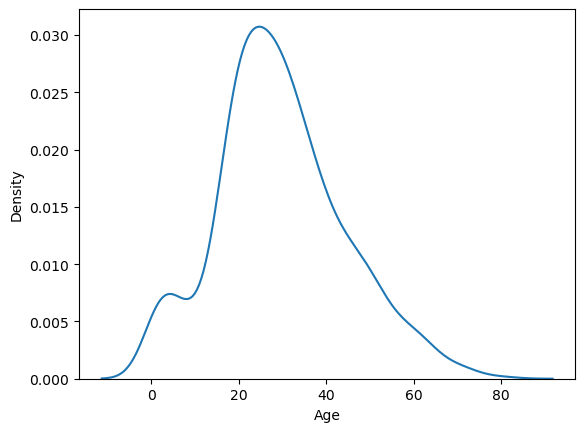

In [7]:
sns.kdeplot(df["Age"])

<Axes: ylabel='Age'>

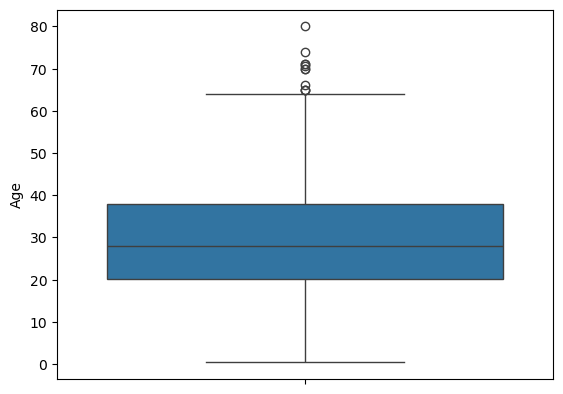

In [8]:
sns.boxplot(df["Age"])

In [9]:
df["Age"].fillna(df["Age"].median(),inplace=True)

In [10]:
df["Embarked"].mode()
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

In [11]:
#df.dropna(inplace=True)

In [12]:
# Null removal
(df.isnull().sum()/len(df))*100

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [13]:
# outlier removal

In [14]:
df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S


In [15]:
df.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)

In [16]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [17]:
# checking statistical distribution
num_cols=["Age","Fare"]
df[num_cols].describe()
# both of them are +vely skewed. Chance of outlier is also there.

,Age,Fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


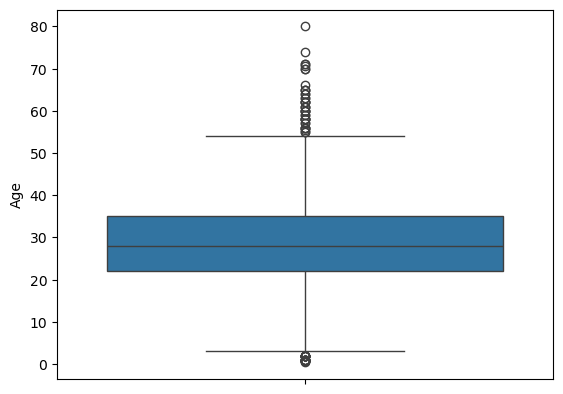

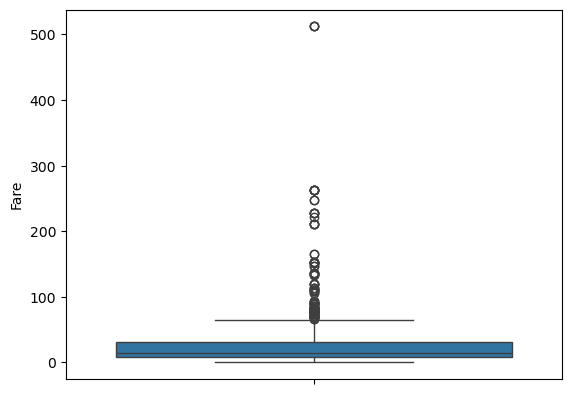

In [18]:
for i in num_cols:
    sns.boxplot(df[i])
    plt.show()
# outliers present so skewness must also be high

In [19]:
from scipy.stats import skew
for i in num_cols:
    print(f"{i} : {skew(df[i])}")

Age : 0.5093852558219663
Fare : 4.7792532923723545


In [20]:
# because age and fare can impact the target prediction
# not processing outliers and skewness

In [21]:
# object encoding

In [22]:
obj_cols=df.select_dtypes("object").columns
obj_cols

Index(['Sex', 'Embarked'], dtype='object')

In [23]:
for i in obj_cols:
    print(f"{i}:{df[i].nunique()} \n {df[i].value_counts()}")

Sex:2 
 Sex
male      577
female    314
Name: count, dtype: int64
Embarked:3 
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [24]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[obj_cols]=oe.fit_transform(df[obj_cols])
df.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1.0,22.0,1,0,7.2500,2.0
1,1,1,0.0,38.0,1,0,71.2833,0.0
2,1,3,0.0,26.0,0,0,7.9250,2.0
3,1,1,0.0,35.0,1,0,53.1000,2.0


In [25]:
obj_cols=["Survived","Pclass","Sex","SibSp","Parch","Embarked"]
for i in obj_cols:
    print(f"{i}:{df[i].nunique()} \n {df[i].value_counts()}")
# Target is Survived and it is imbalanced

Survived:2 
 Survived
0    549
1    342
Name: count, dtype: int64
Pclass:3 
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex:2 
 Sex
1.0    577
0.0    314
Name: count, dtype: int64
SibSp:7 
 SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Parch:7 
 Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
Embarked:3 
 Embarked
2.0    646
0.0    168
1.0     77
Name: count, dtype: int64


Survived


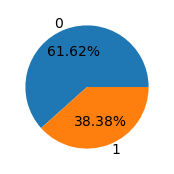

Pclass


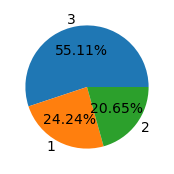

Sex


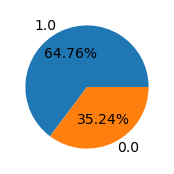

SibSp


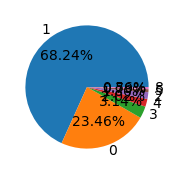

Parch


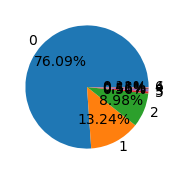

Embarked


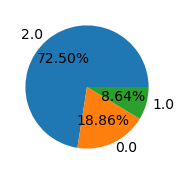

In [26]:
for i in obj_cols:
    print(f"{i}")
    plt.figure(figsize=(2,2))
    plt.pie(df[i].value_counts(),autopct="%.2f%%",labels=df[i].unique())
    plt.show()
#

In [27]:
df["Family Size"]=df["SibSp"]+df["Parch"]
df["Family Size"].value_counts()

Family Size
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64

In [28]:
df.drop(["SibSp","Parch"],axis=1,inplace=True)

In [29]:
df.head(1)

,Survived,Pclass,Sex,Age,Fare,Embarked,Family Size
0,0,3,1.0,22.0,7.25,2.0,1


In [30]:
#logistic regression there is no feature selection.

Feature : Survived


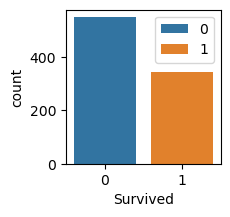

Feature : Pclass


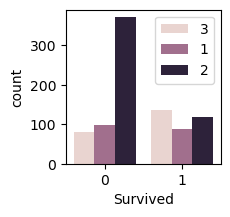

Feature : Sex


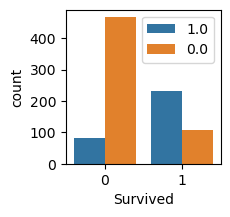

Feature : Family Size


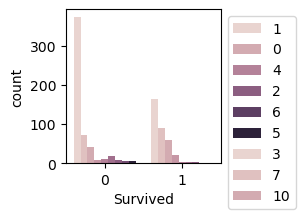

Feature : Embarked


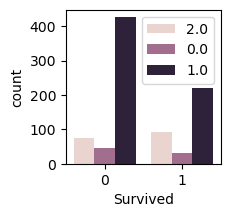

In [31]:
obj_cols=['Survived', 'Pclass', 
          'Sex','Family Size' , 'Embarked']
for i in obj_cols:
    print(f"Feature : {i}")
    plt.figure(figsize=(2,2))
    sns.countplot(data=df,x="Survived",hue=i)
    plt.legend(df[i].unique(),
              bbox_to_anchor=(1,1),loc="best")
    plt.show()
#

Feature : Age


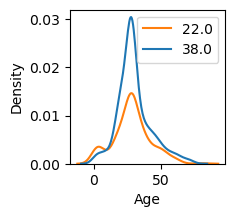

Feature : Fare


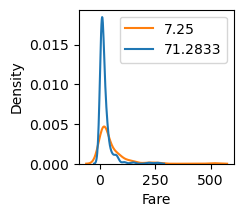

In [32]:
c=["Age","Fare"]
for i in c:
    print(f"Feature : {i}")
    plt.figure(figsize=(2,2))
    sns.kdeplot(data=df,x=i,hue="Survived")
    plt.legend(df[i].unique(),
              bbox_to_anchor=(1,1),loc="best")
    plt.show()

In [33]:
features=df.drop("Survived",axis=1)
target=df["Survived"]

In [34]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
features.iloc[:]=ss.fit_transform(features.iloc[:])
features

,Pclass,Sex,Age,Fare,Embarked,Family Size
0,0.827377,0.737695,-0.565736,-0.502445,0.585954,0.059160
1,-1.566107,-1.355574,0.663861,0.786845,-1.942303,0.059160
2,0.827377,-1.355574,-0.258337,-0.488854,0.585954,-0.560975
3,-1.566107,-1.355574,0.433312,0.420730,0.585954,0.059160
4,0.827377,0.737695,0.433312,-0.486337,0.585954,-0.560975
...,...,...,...,...,...,...
886,-0.369365,0.737695,-0.181487,-0.386671,0.585954,-0.560975
887,-1.566107,-1.355574,-0.796286,-0.044381,0.585954,-0.560975
888,0.827377,-1.355574,-0.104637,-0.176263,0.585954,1.299429
889,-1.566107,0.737695,-0.258337,-0.044381,-1.942303,-0.560975


In [35]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,
                                          random_state=1,
                                          test_size=0.2)

In [36]:
print(xtrain.shape,ytrain.shape)
print(xtest.shape,ytest.shape)

(712, 6) (712,)
(179, 6) (179,)


In [37]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0)
clf.fit(xtrain, ytrain)
ypred=clf.predict(xtest)

In [38]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [40]:
c=pd.DataFrame(confusion_matrix(ypred,ytest),
              columns=["Not Survived","Survived"],
              index=["Not Survived","Survived"])
print(c)
print("-------------")
print(classification_report(ypred,ytest))

              Not Survived  Survived
Not Survived            90        19
Survived                16        54
-------------
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       109
           1       0.74      0.77      0.76        70

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.80       179
weighted avg       0.81      0.80      0.81       179



In [42]:
# overfitting - underfitting check
print(f"Training Score : {clf.score(xtrain,ytrain)}")
print(f"Testing Score : {clf.score(xtest,ytest)}")

Training Score : 0.7991573033707865
Testing Score : 0.8044692737430168


In [47]:
print("Actual : ",ytest[:10].values)
print("Predic : ",clf.predict(xtest[:10].values))


Actual :  [1 0 1 0 1 0 0 1 0 1]
Predic :  [1 0 1 1 1 0 0 1 1 1]


In [50]:
clf.predict_proba(xtest[:10])

array([[0.12252857, 0.87747143],
       [0.91394371, 0.08605629],
       [0.12160882, 0.87839118],
       [0.35740583, 0.64259417],
       [0.11689688, 0.88310312],
       [0.89018842, 0.10981158],
       [0.86428383, 0.13571617],
       [0.09025751, 0.90974249],
       [0.42793082, 0.57206918],
       [0.39751092, 0.60248908]])

In [51]:
from sklearn.metrics import roc_auc_score,roc_curve
print("ROC_AUC Score ",roc_auc_score(ytest,ypred) )

ROC_AUC Score  0.7943913155854225


Text(0, 0.5, 'TPR')

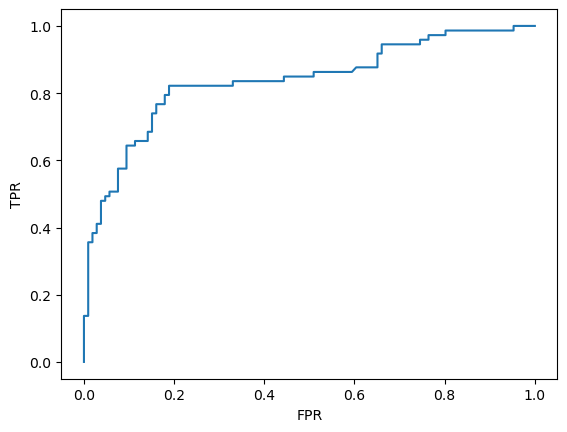

In [57]:
# Plotting ROC_Cuirve
yp=clf.predict_proba(xtest)[:,1]
fpr,tpr,th=roc_curve(ytest,yp)
plt.plot(fpr,tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")

In [58]:
th

array([       inf, 0.96996764, 0.93683341, 0.91690368, 0.76907307,
       0.76889415, 0.76315547, 0.75960696, 0.7460751 , 0.73408816,
       0.69006902, 0.66403753, 0.65524867, 0.64684153, 0.64649581,
       0.64259417, 0.64254505, 0.61049611, 0.60676203, 0.59659906,
       0.58854274, 0.58809414, 0.57206918, 0.55566106, 0.54609865,
       0.50146298, 0.49779993, 0.4710912 , 0.43272852, 0.41558505,
       0.40258866, 0.34295316, 0.27219919, 0.27133832, 0.24880611,
       0.2349105 , 0.15407479, 0.13575903, 0.12427355, 0.12229956,
       0.10606418, 0.10446739, 0.09560853, 0.08917458, 0.08894257,
       0.08818934, 0.08612595, 0.08606299, 0.08605629, 0.08605105,
       0.08480823, 0.08313679, 0.08247835, 0.08151606, 0.05169912,
       0.04832955, 0.02138415, 0.01667028])

In [61]:
from sklearn.metrics import f1_score
f1=[f1_score(ytest,(yp>=t).astype(int)) for t in th]

In [67]:
best_t=th[np.argmax(f1)]

In [70]:
best_t=round(best_t,2)

In [73]:
from sklearn.preprocessing import binarize
ypred_proba = clf.predict_proba(xtest)[:,1]
ypr=binarize([ypred_proba],threshold=best_t)[0]
ypr=ypr.astype(int)
print("roc_score : ",roc_auc_score(ytest,ypr))

roc_score :  0.8166192814680796


In [75]:
c=pd.DataFrame(confusion_matrix(ypr,ytest),
              columns=["Not Survived","Survived"],
              index=["Not Survived","Survived"])
print(c)
print("-------------")
print(classification_report(ypr,ytest))

              Not Survived  Survived
Not Survived            86        13
Survived                20        60
-------------
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        99
           1       0.82      0.75      0.78        80

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.81       179

